<p style="font-family: Arial; font-size:2.5em;color:green; font-style:bold"><br>
Employee Attrition
</p><br>

In [12]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

We will analyze a dataset of employees to gain insights on employee attrition. You may refer to the Word document for data description and variable definitions.

In [13]:
# Import packages: pandas, matplotlib, seaborn, statsmodels, etc.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [14]:
df = pd.read_csv('/Employee_Attrition.csv')

In [ ]:
# Check basic information using .info(), .columns and .head()
df.info()
df.columns
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


1. Understand the dataset. There are 35 variables. To better understand them, we can conceptually organize them into different categories. Use the Word document, categorize the variable names to their corresponding categories and write them in the cell below. I wrote one as an example. <br>
After this exercise, you will have a clear picture of the variables and what they measure.

In [ ]:
# Identifier
  # 'EmployeeNumber'

# Attrition
  # 'Attrition'

# Employee demographics
  # 'Age', 'Education', 'EducationField', 'Gender', 'MaritalStatus'

# Job-related
  # 'BusinessTravel', 'Department','JobInvolvement', 'JobLevel', 'JobRole'
  # 'JobSatisfaction','OverTime'

# Work environment
  # 'DistanceFromHome', 'EnvironmentSatisfaction', 'RelationshipSatisfaction','WorkLifeBalance'

# Compensation
 # 'DailyRate', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate','PercentSalaryHike',
 #  'StockOptionLevel'

# Performance
 # 'PerformanceRating'

# Job history
 # 'TotalWorkingYears', 'TrainingTimesLastYear', 'NumCompaniesWorked'
 # 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager'

# Variables with constant values for the whole dataset
 # 'EmployeeCount', 'Over18', 'StandardHours'

2. For the purpose of building a model to predict attrition, which variable is the target variable? Explore this variable distribution. How many employees have left the company?

Attrition distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


<Figure size 600x400 with 0 Axes>

<Axes: xlabel='Attrition', ylabel='count'>

Text(0.5, 1.0, 'Employee Attrition Distribution')

Text(0.5, 0, 'Attrition (Yes = Left, No = Stayed)')

Text(0, 0.5, 'Number of Employees')

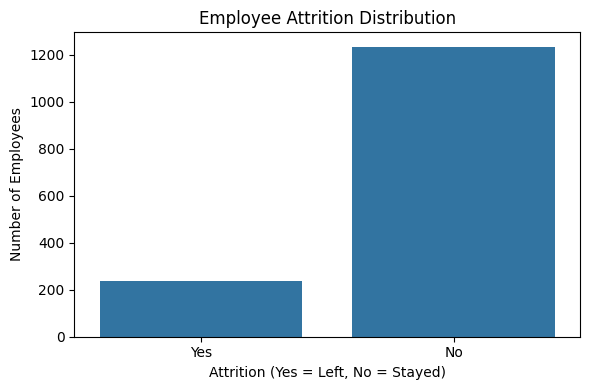

In [ ]:
attrition_counts = df['Attrition'].value_counts()
print("Attrition distribution:")
print(attrition_counts)
#print("\nNumber of employees who left the company:", attrition_counts['Yes'])

# Visualizing the distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Attrition', data=df)
plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition (Yes = Left, No = Stayed)')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()


3. Let's start to prepare the data for analysis. First, we can drop the following variables: the identifier and variables with constant values. They do not contribute any information to the analysis.

In [ ]:
columns_to_drop = ['EmployeeNumber', 'Over18', 'EmployeeCount', 'StandardHours']
df = df.drop(columns=columns_to_drop)

# Confirm changes
print("Remaining columns:", df.columns.tolist())
print("\nData shape after dropping:", df.shape)

Remaining columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data shape after dropping: (1470, 31)


4. We may expect the variables of compensation may be correlated with each other. For instance, montly income and monthly rate should be correlated. Please explore the correlation between them using both numbers and a graph. Do the same for 'DailyRate', 'HourlyRate' and 'MonthlyRate'. What do you find?

Correlation matrix:

                   MonthlyIncome  MonthlyRate  DailyRate  HourlyRate  \
MonthlyIncome           1.000000     0.034814   0.007707   -0.015794   
MonthlyRate             0.034814     1.000000  -0.032182   -0.015297   
DailyRate               0.007707    -0.032182   1.000000    0.023381   
HourlyRate             -0.015794    -0.015297   0.023381    1.000000   
PercentSalaryHike      -0.027269    -0.006429   0.022704   -0.009062   
StockOptionLevel        0.005408    -0.034323   0.042143    0.050263   

                   PercentSalaryHike  StockOptionLevel  
MonthlyIncome              -0.027269          0.005408  
MonthlyRate                -0.006429         -0.034323  
DailyRate                   0.022704          0.042143  
HourlyRate                 -0.009062          0.050263  
PercentSalaryHike           1.000000          0.007528  
StockOptionLevel            0.007528          1.000000  


<Figure size 800x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Heatmap of Compensation Variables')

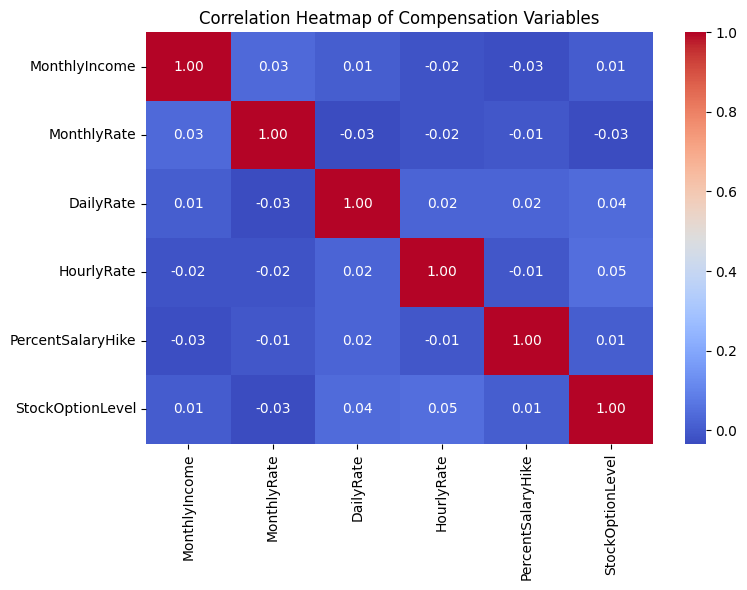

In [ ]:
#Define compensation-related variables
comp_vars = ['MonthlyIncome', 'MonthlyRate', 'DailyRate', 'HourlyRate', 'PercentSalaryHike', 'StockOptionLevel']

#Correlation matrix
comp_corr_matrix = df[comp_vars].corr()

#Print correlation matrix
print("Correlation matrix:\n")
print(comp_corr_matrix)

#Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(comp_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Compensation Variables")
plt.tight_layout()
plt.show()

I checked if salary-related variables like MonthlyIncome, MonthlyRate, DailyRate, and HourlyRate are connected. Surprisingly, they aren’t. MonthlyIncome doesn’t really align with MonthlyRate, and the rate variables seem random or system-generated. So, I decided they don’t add much value and dropped them from the analysis.











5. Make histograms for all the compensation variables. What do you find?

<Figure size 1800x1000 with 0 Axes>

<Axes: >

(array([58., 44., 45., 41., 57., 42., 39., 56., 42., 60., 59., 50., 62.,
        41., 37., 52., 45., 50., 51., 43., 33., 60., 48., 54., 51., 47.,
        60., 58., 39., 46.]),
 array([ 102.        ,  148.56666667,  195.13333333,  241.7       ,
         288.26666667,  334.83333333,  381.4       ,  427.96666667,
         474.53333333,  521.1       ,  567.66666667,  614.23333333,
         660.8       ,  707.36666667,  753.93333333,  800.5       ,
         847.06666667,  893.63333333,  940.2       ,  986.76666667,
        1033.33333333, 1079.9       , 1126.46666667, 1173.03333333,
        1219.6       , 1266.16666667, 1312.73333333, 1359.3       ,
        1405.86666667, 1452.43333333, 1499.        ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribution of DailyRate')

Text(0.5, 0, 'DailyRate')

...

<Axes: >

(array([631.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 596.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 158.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,  85.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7, 2.8, 2.9, 3. ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribution of StockOptionLevel')

Text(0.5, 0, 'StockOptionLevel')

Text(0, 0.5, 'Frequency')

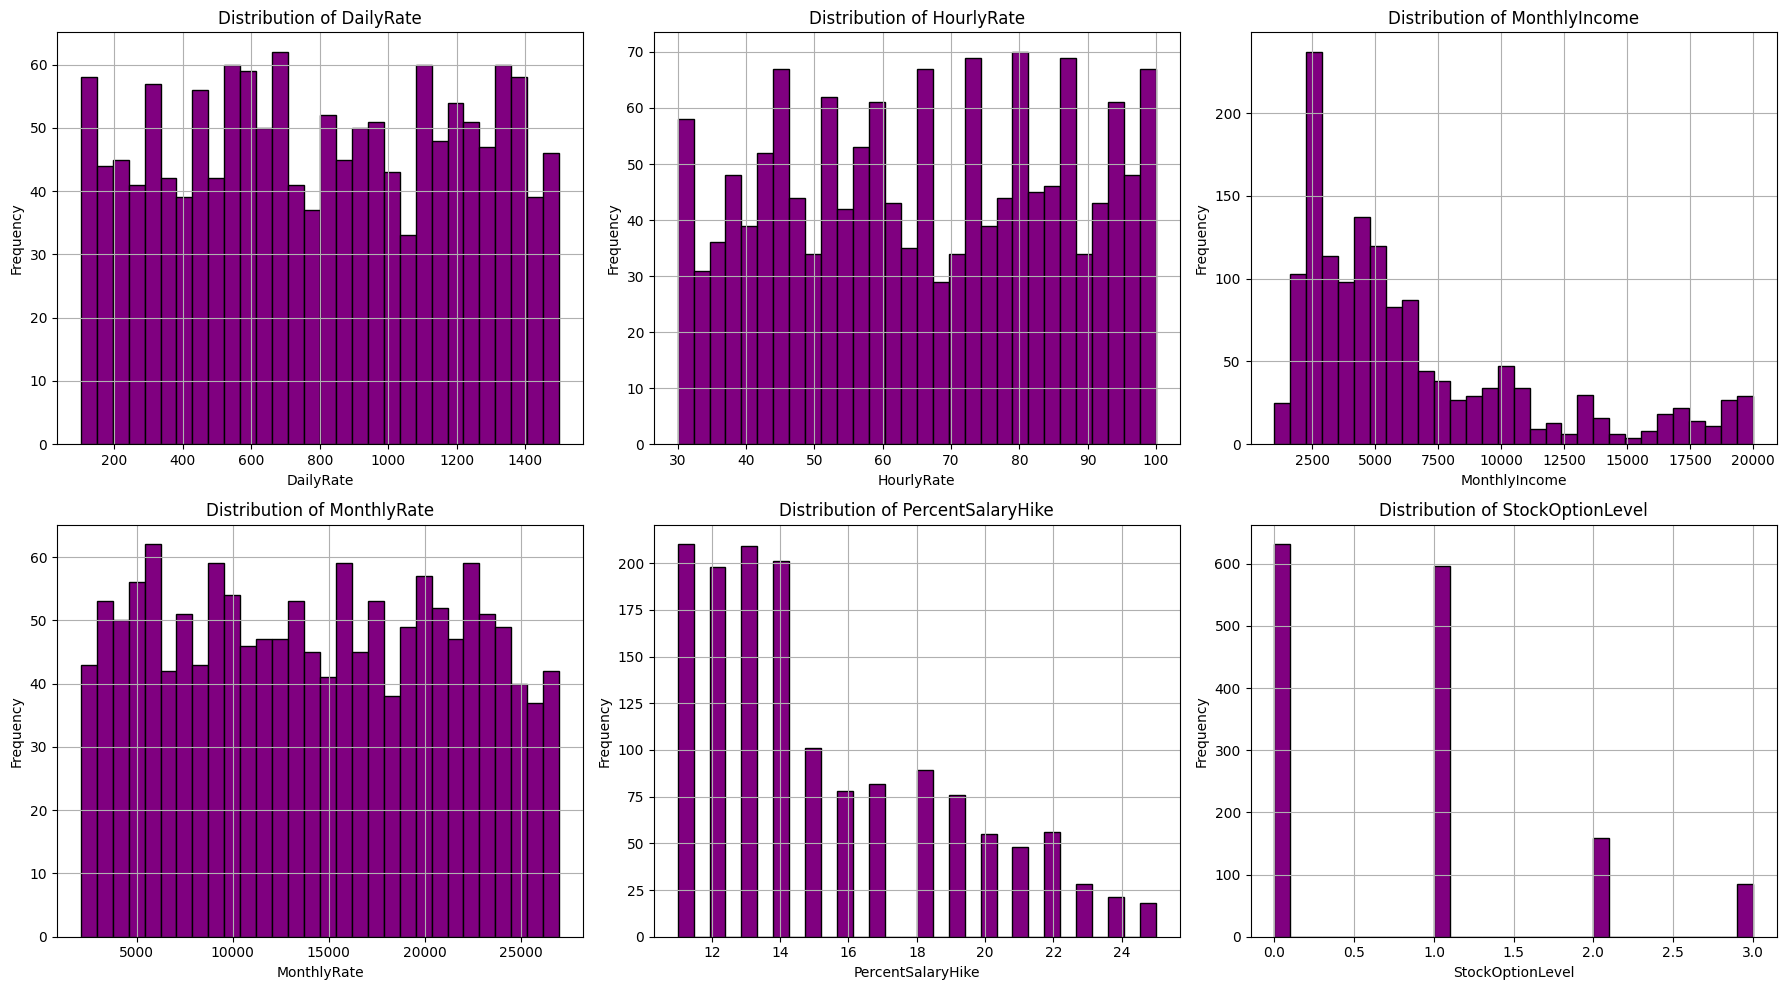

In [ ]:

# Updated list of compensation-related variables
comp_vars = ['DailyRate', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike', 'StockOptionLevel']

# Plot histograms for each compensation variable
plt.figure(figsize=(18, 10))

for i, var in enumerate(comp_vars):
    plt.subplot(2, 3, i + 1)
    plt.hist(df[var], bins=30, color='purple', edgecolor='black')
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.grid(True)

plt.tight_layout()
plt.show()

The distribution of 'MonthlyIncome', 'PercentSalaryHike' and 'StockOptionLevel' seem to follow a skewed normal distribution that fit our common sense, but the rate variable distributions do not seem so. So, we decide to drop the rate variables.

In [ ]:
df = df.drop(columns=['DailyRate', 'HourlyRate', 'MonthlyRate'])

#Show remaining compensation variables
print("Remaining compensation-related variables:")
print([col for col in df.columns if 'Income' in col or 'SalaryHike' in col or 'StockOption' in col])

Remaining compensation-related variables:
['MonthlyIncome', 'PercentSalaryHike', 'StockOptionLevel']


6. Make a graph to examine the relationship between 'Attrition' and 'MonthlyIncome'. What do you find?

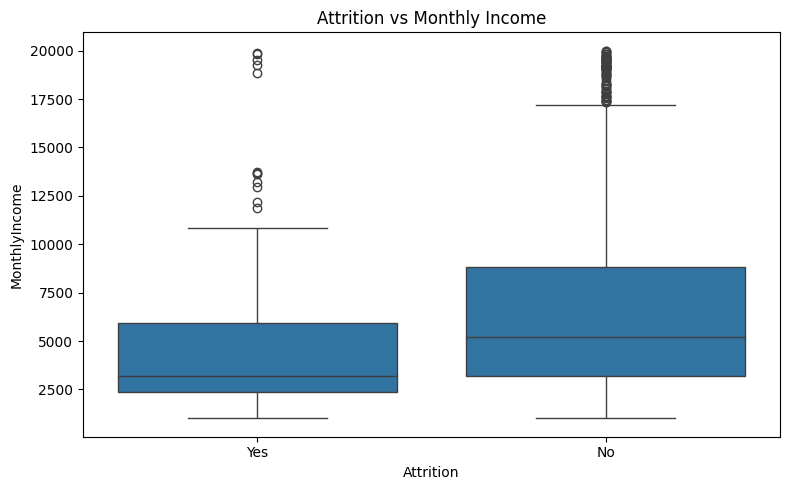

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Attrition vs Monthly Income')
plt.tight_layout()
plt.show()


Based on the exploration of Step 4, 5, and 6. We may decide that to include only 'MonthlyIncome', 'PercentSalaryHike', and 'StockOptionLevel' in the model. (The correlation analysis is not consistent with our common sense, which may indicate that the rate variables may have problems. So, we decide not to use them.)

7. Let's move to explore demographic variables, using the education variables as an example. I made a graph to examine their combined distribution, which can represent the pivot table of the two variables. From the graph, you may find that most employees are in the fields of life sciences and medical. Bachelor's degrees are the most across fields.<br>
<br>
<I>Now you may pick one variable in demographics to explore its relationship with Attrition. For categorical variables, you may use the countplot as in my example to display.</I>

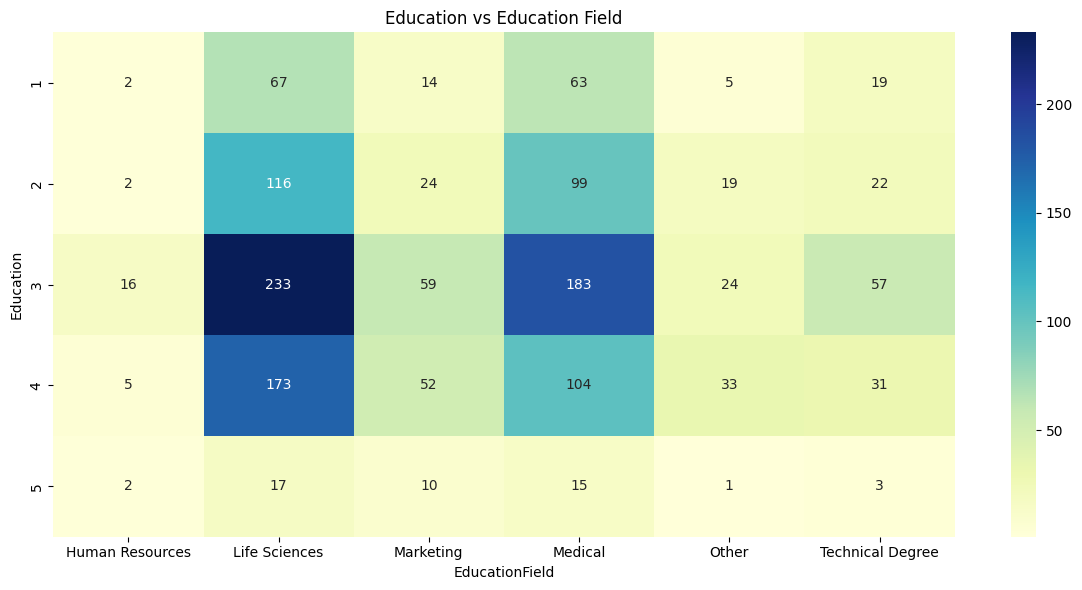

In [ ]:
pivot = pd.pivot_table(df, index='Education', columns='EducationField',
                       values='Attrition', aggfunc='count', fill_value=0)
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Education vs Education Field')
plt.tight_layout()
plt.show()



In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data = attrition, x = 'EducationField', hue = 'Education')
ax.legend(title='Education', labels=['Below College', 'College', 'Bachelor', 'Master', 'Doctor'])

8. Next is to the category of 'Job related'. Examine 'JobRole' with two graphs: its distrition and relationship with Attrition. What do you find? Which roles are more likely to leave?

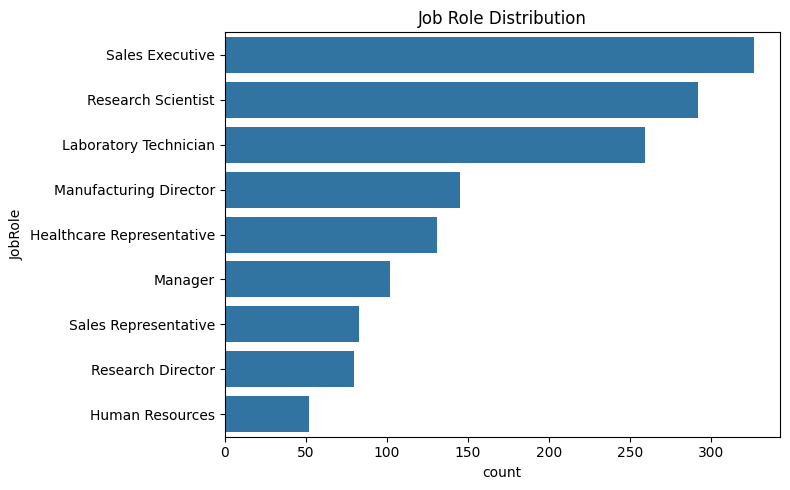

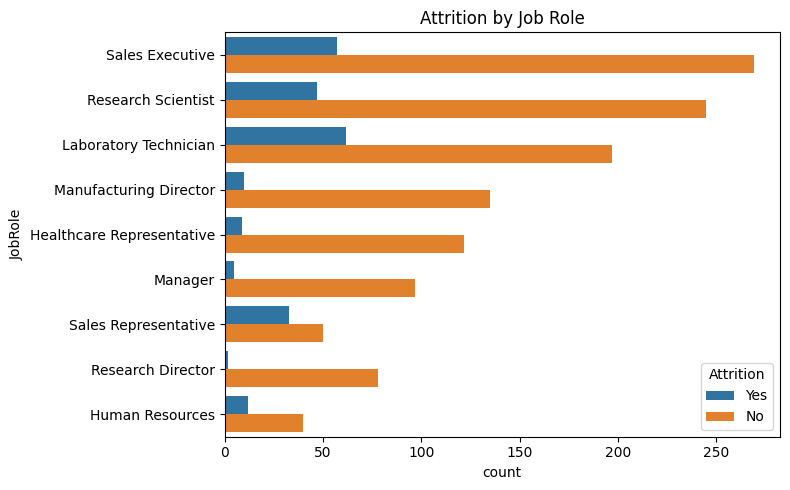

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(y='JobRole', data=df, order=df['JobRole'].value_counts().index)
plt.title('Job Role Distribution')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(y='JobRole', hue='Attrition', data=df, order=df['JobRole'].value_counts().index)
plt.title('Attrition by Job Role')
plt.tight_layout()
plt.show()

I did the same for every job related variables. I intended to explore whether these variables play a role and the results will guide the model building later. The conclusion is that all these variables seem to be relevant to attrition outcome.

In [ ]:
for var in ['BusinessTravel', 'Department','JobInvolvement', 'JobLevel', 'JobRole',
  'JobSatisfaction','OverTime']:
   # if attrition[var].dtype == 'int64':
    #    plt.figure(figsize=(10, 6))
     #   sns.boxplot(data = attrition, x = 'Attrition', y = var)
      #  plt.show()
    #else:
        plt.figure(figsize=(10, 6))
        sns.countplot(data = df, x = 'Attrition', hue = var)
        plt.show()

# More likely to leave:
  # Frequent traveler
  # Sales department
  # Low job involvement
  # Level 1 jobs
  # Sales related roles
  # low job satisfaction
  # More overtime

NameError: name 'plt' is not defined

9. Let's move to work environment features. Similarly, pick one variable to examine its distritbution and relationship with attrition. Report your findings.

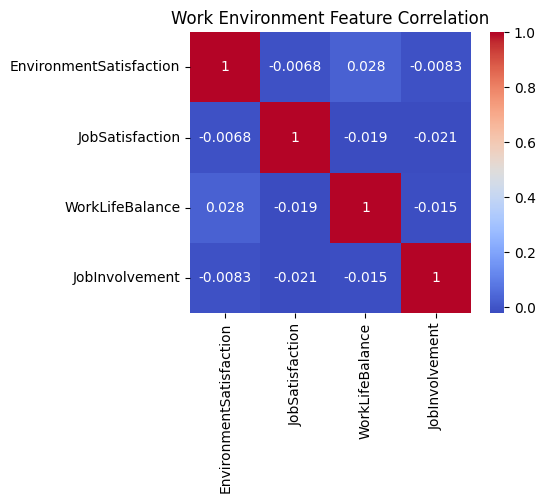

In [ ]:
env_vars = ['EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement']
plt.figure(figsize=(6, 5))
sns.heatmap(df[env_vars].corr(), annot=True, cmap='coolwarm', square=True)
plt.title("Work Environment Feature Correlation")
plt.tight_layout()
plt.show()


I explored all these variables and decided that we will include them in the model.

10. The last group of variables is about work history.

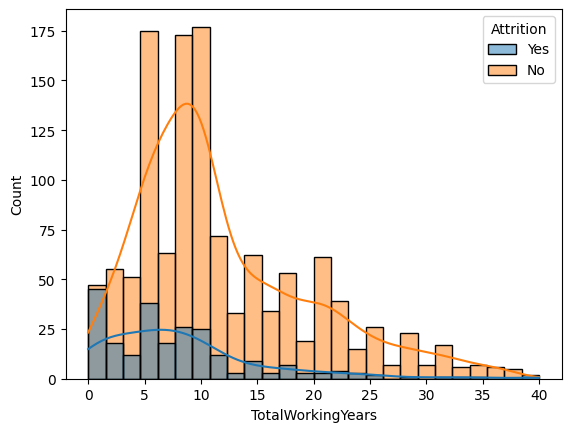

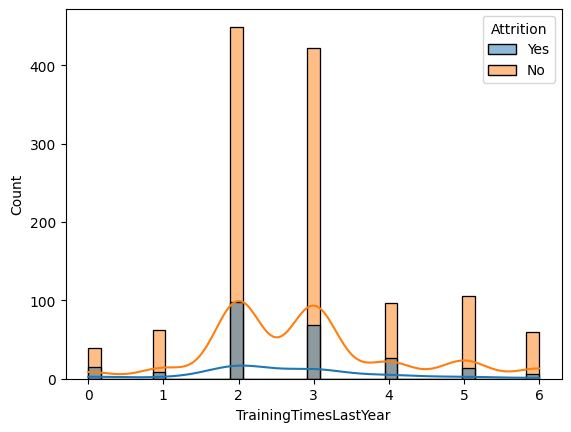

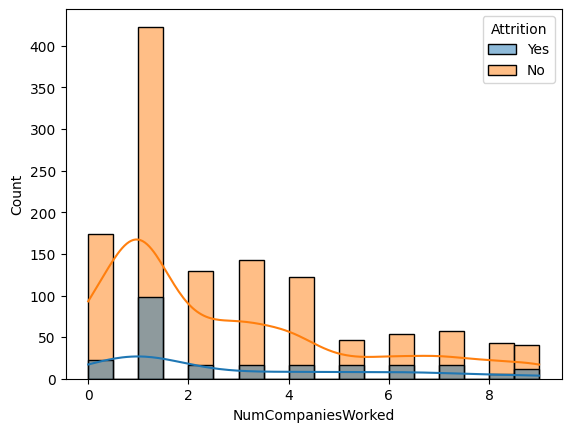

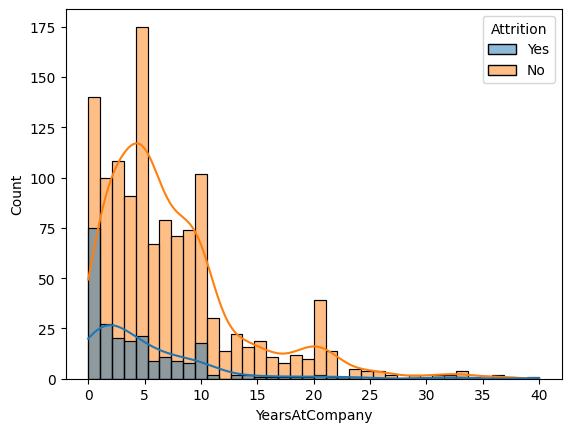

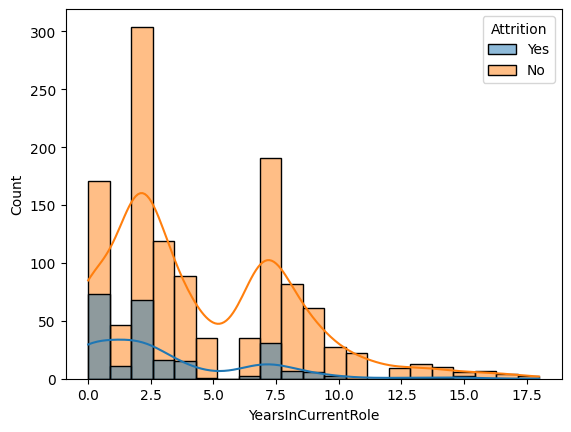

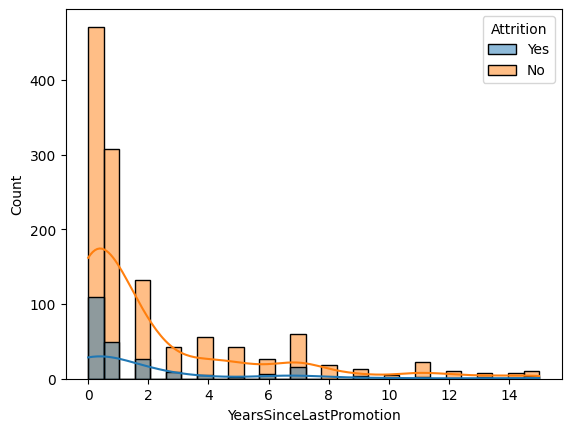

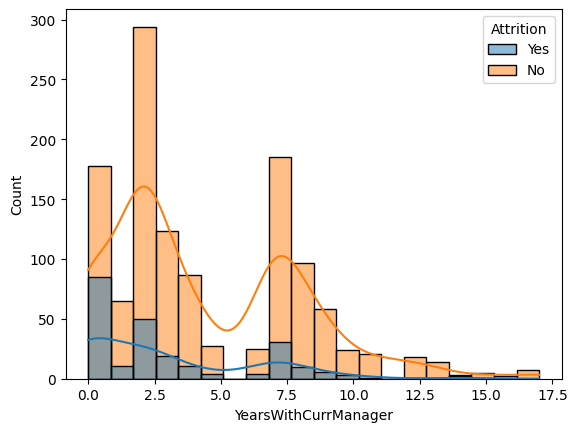

In [ ]:
history_variables = ['TotalWorkingYears', 'TrainingTimesLastYear', 'NumCompaniesWorked',
 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']
for var in history_variables:
    sns.histplot(data=df, x=var, hue='Attrition', kde=True)
    plt.show()

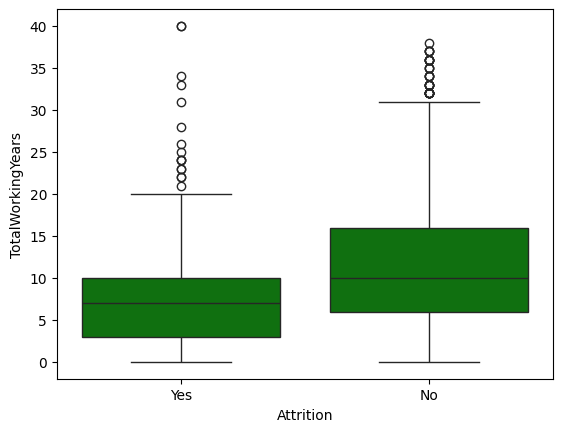

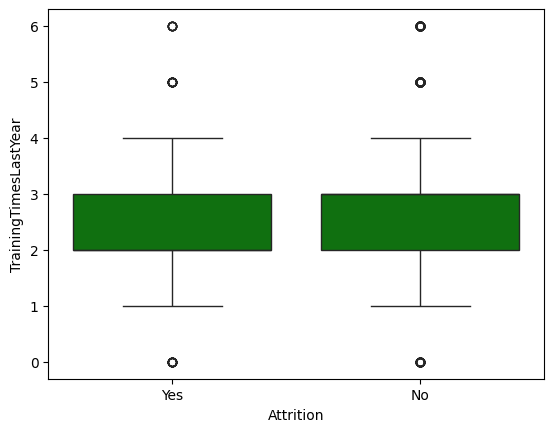

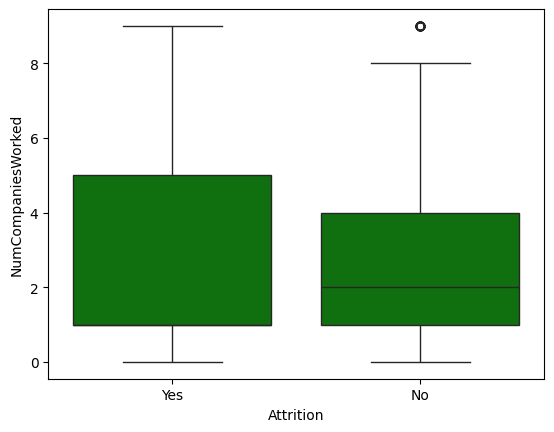

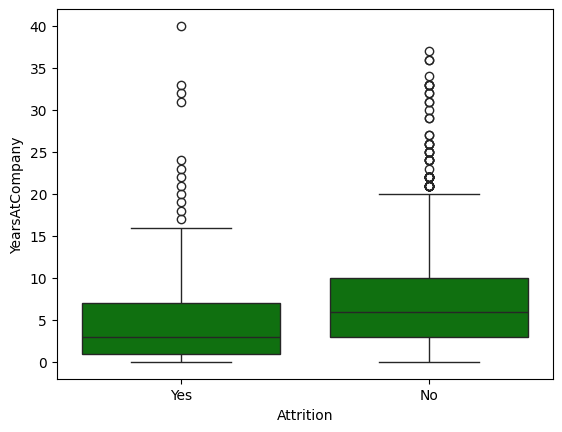

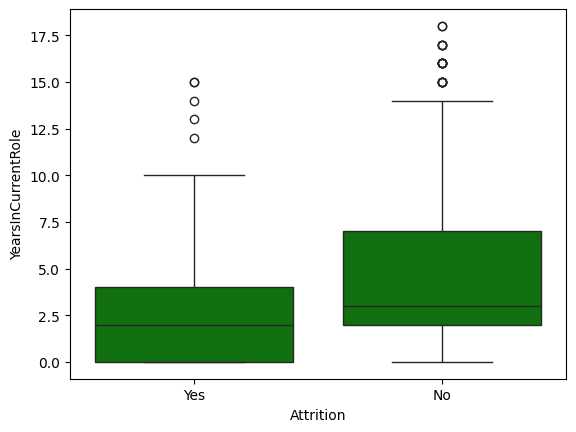

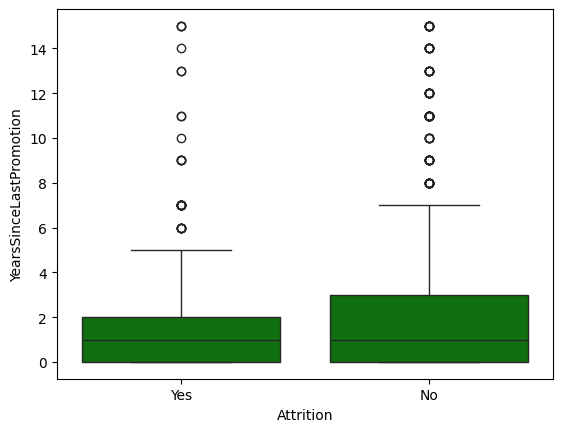

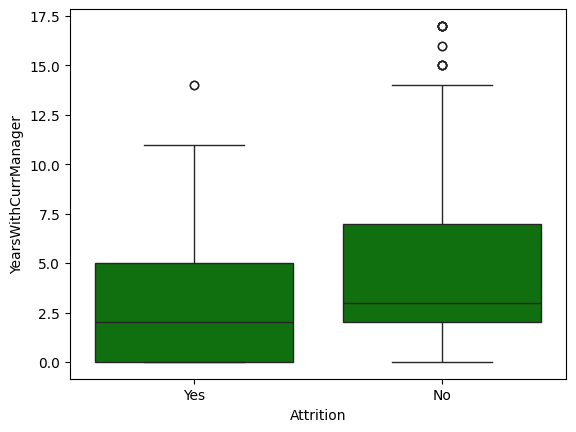

In [ ]:
for var in history_variables:
    sns.boxplot(data=df, x='Attrition', y=var, color='green')
    plt.show()

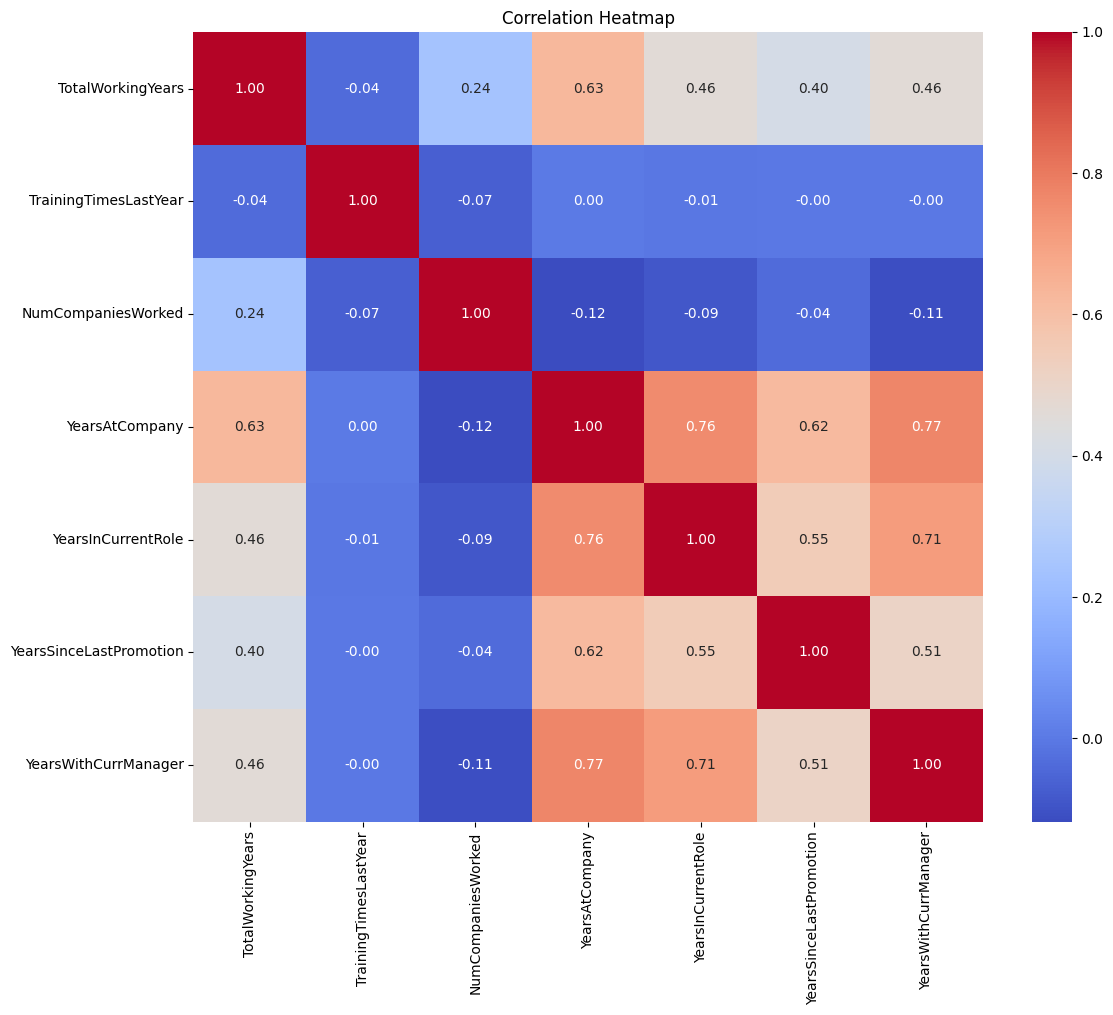

In [ ]:
# Plot the correlation matrix of history variables
hist_corr = df[history_variables].corr()
# ploting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(hist_corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = add_constant(df[history_variables])
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIFactor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]


In [ ]:
vif

,Variable,VIFactor
0,const,9.614324
1,TotalWorkingYears,1.979328
2,TrainingTimesLastYear,1.005278
3,NumCompaniesWorked,1.217294
4,YearsAtCompany,4.494398
5,YearsInCurrentRole,2.668855
6,YearsSinceLastPromotion,1.663605
7,YearsWithCurrManager,2.724068


I checked their collinearity using correlation and VIF. Although VIF values are not very alarming, I still decide to drop 'YearsAtCompany', as it is highly correlated with two other variables 'YearsInCurrentRole' and 'YearsWithCurrManager'.

In [ ]:
df.drop('YearsAtCompany', axis = 1, inplace = True)

11. I checked for missing values and did not find any.  Please refer to the slides "Data Preparation - Feature Engineering" for detailed information about what we need to do to prepare features for our model building.<br>
Let's assume we do not need generate new features.

In [ ]:
df.isna().sum()
# checking for no missing values

,0
Age,0
Attrition,0
BusinessTravel,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0
EnvironmentSatisfaction,0


12. Finally, we will code the categorical variables. Some variables have already been ordinally coded, such as Education and the satisfaction variables.<br>
We have the following categorical variables to be coded.<br>
['BusinessTravel', 'Department',
       'EducationField', 'Gender', 'JobRole', 'MaritalStatus',
       'OverTime']<br>
We will use dummy variable (one-hot coding) for them.<br>
Let's prepare our X and y: target variable 'Attrition' and the rest are predictor variables. Code the dummy variables for X.

In [ ]:

#Define categorical variables to one-hot encode
cat_vars = ['BusinessTravel', 'Department', 'EducationField', 'Gender',
            'JobRole', 'MaritalStatus', 'OverTime']

#Create X and y
X = pd.get_dummies(df.drop('Attrition', axis=1), columns=cat_vars, drop_first=True)
y = df['Attrition']

# Confirm result
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
X.head()

Shape of X: (1470, 44)
Shape of y: (1470,)


,Age,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,2,1,1,2,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,8,1,1,2,3,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,2,2,1,4,4,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,3,4,1,5,4,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,2,1,1,7,1,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False


13. Split training and test dataset

In [ ]:
#Importing train_test_split
from sklearn.model_selection import train_test_split

#split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3: Confirm the split
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (1176, 44)
Test set size: (294, 44)


14. Use a logistic regression model to examine which variables play a significant role in employee attrition.

In [ ]:
import pandas as pd
import statsmodels.api as sm

# Step 1: Drop irrelevant columns if they exist
df = df.drop(columns=['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18'], errors='ignore')

# Step 2: Convert target variable to numeric (Yes = 1, No = 0)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Step 3: Define predictors and target
y = df['Attrition']
X = df.drop('Attrition', axis=1)

# Step 4: One-hot encode categorical variables
cat_vars = ['BusinessTravel', 'Department', 'EducationField', 'Gender',
            'JobRole', 'MaritalStatus', 'OverTime']
X = pd.get_dummies(X, columns=cat_vars, drop_first=True)

# Step 5: Add constant and convert to float
X_const = sm.add_constant(X).astype(float)
y = y.astype(float)

# Step 6: Fit logistic regression model
logit_model = sm.Logit(y, X_const)
result = logit_model.fit()

# Step 7: Display summary
print(result.summary())

         Current function value: 0.294779
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:              Attrition   No. Observations:                 1470
Model:                          Logit   Df Residuals:                     1429
Method:                           MLE   Df Model:                           40
Date:                Mon, 07 Apr 2025   Pseudo R-squ.:                  0.3326
Time:                        00:16:53   Log-Likelihood:                -433.32
converged:                      False   LL-Null:                       -649.29
Covariance Type:            nonrobust   LLR p-value:                 3.272e-67
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                               -10.0758    577.808     -0.017      0.986   -1142.559    1122.

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


15. Build two decision tree models (by varying the tree parameters) to make predictions. Evaluate your results using performance metrics we have learned.


📊 Evaluation: Decision Tree 1 (max_depth=3)
Confusion Matrix:
 [[235  12]
 [ 37  10]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.95      0.91       247
         1.0       0.45      0.21      0.29        47

    accuracy                           0.83       294
   macro avg       0.66      0.58      0.60       294
weighted avg       0.80      0.83      0.81       294


📊 Evaluation: Decision Tree 2 (max_depth=10, min_samples_split=5)
Confusion Matrix:
 [[224  23]
 [ 28  19]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.89      0.91      0.90       247
         1.0       0.45      0.40      0.43        47

    accuracy                           0.83       294
   macro avg       0.67      0.66      0.66       294
weighted avg       0.82      0.83      0.82       294



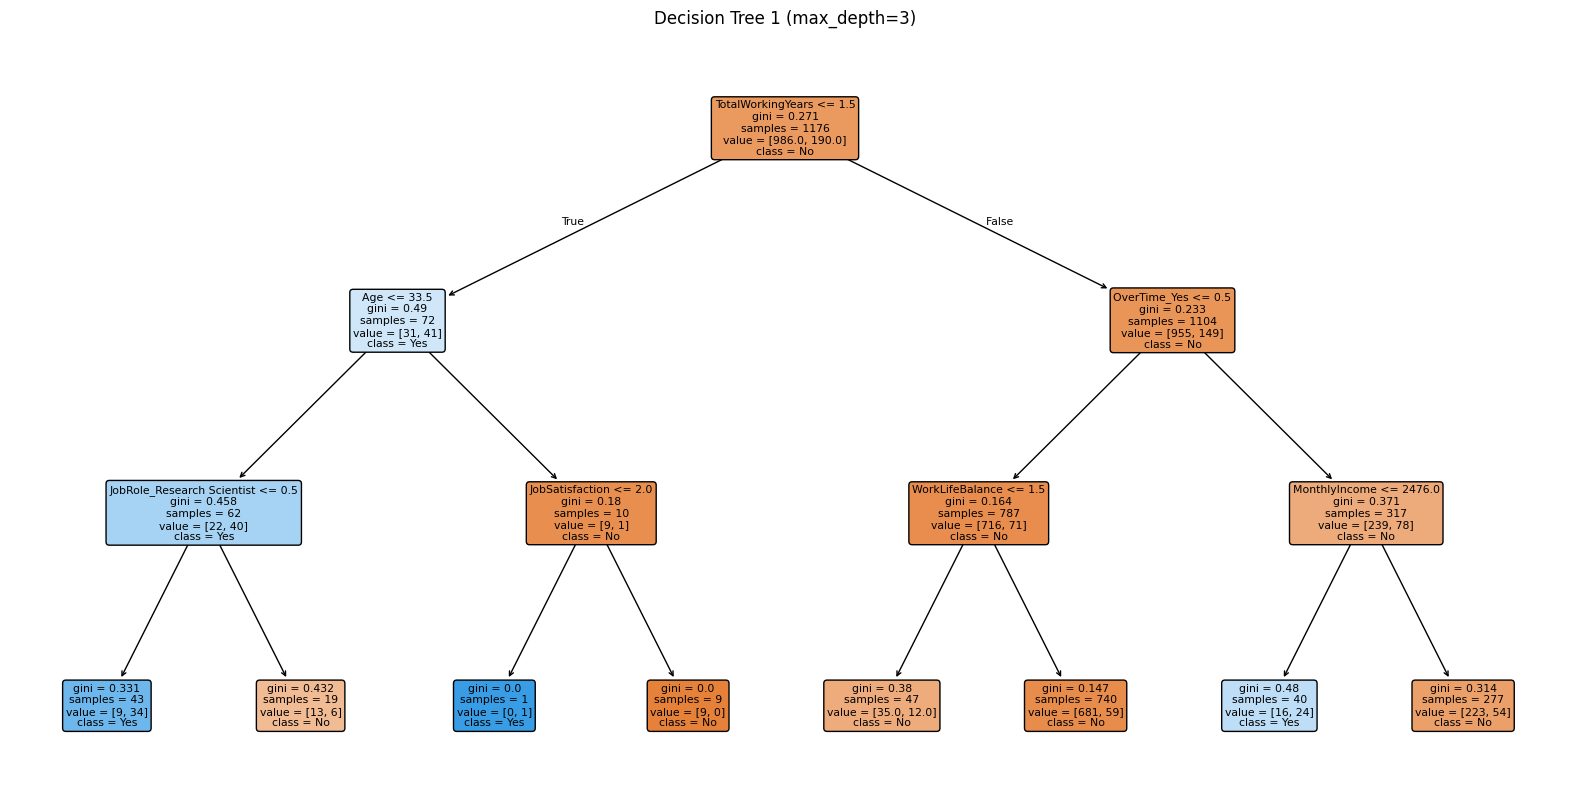

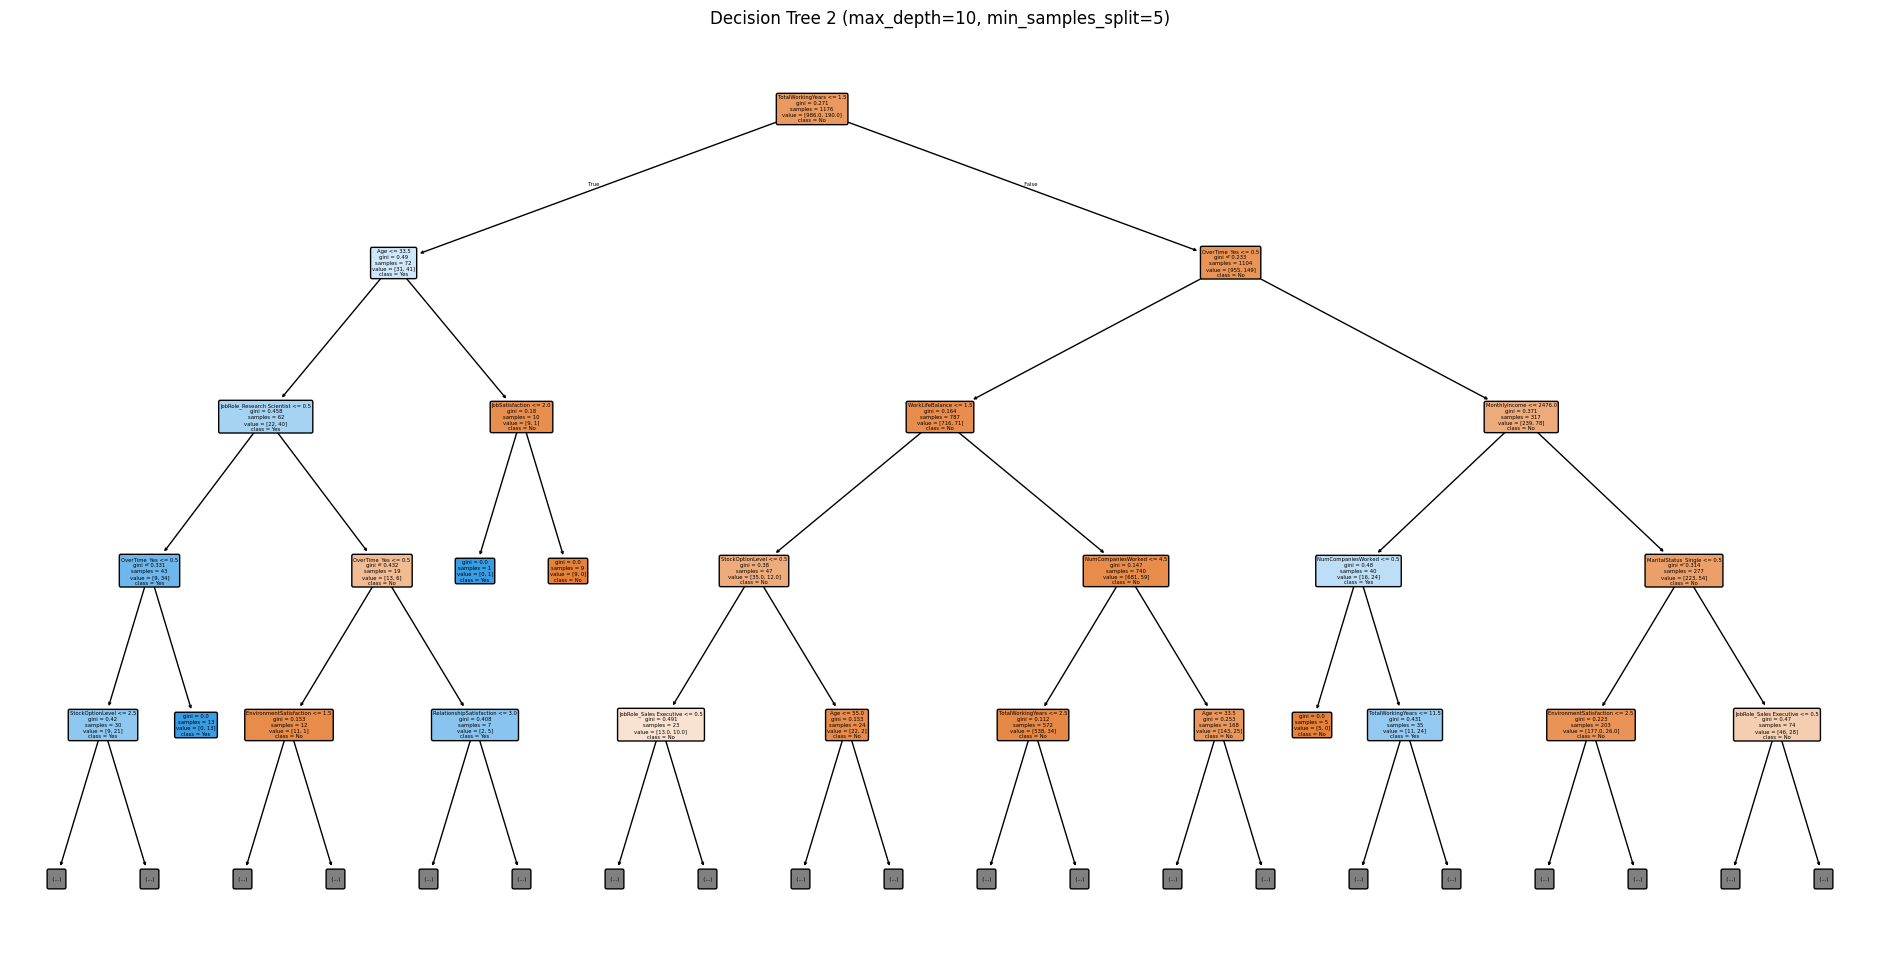

In [ ]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree

#Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build two decision tree models with different parameters
#Simpler tree
tree1 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree1.fit(X_train, y_train)
y_pred1 = tree1.predict(X_test)

#Deeper tree
tree2 = DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=42)
tree2.fit(X_train, y_train)
y_pred2 = tree2.predict(X_test)

#Evaluation function
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n📊 Evaluation: {model_name}")
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

#Evaluate both models
evaluate_model(y_test, y_pred1, "Decision Tree 1 (max_depth=3)")
evaluate_model(y_test, y_pred2, "Decision Tree 2 (max_depth=10, min_samples_split=5)")

# Plot Decision Tree 1
plt.figure(figsize=(20, 10))
plot_tree(tree1,
          feature_names=X.columns,
          class_names=["No", "Yes"],
          filled=True,
          rounded=True,
          max_depth=3)
plt.title("Decision Tree 1 (max_depth=3)")
plt.show()

# Plot Decision Tree 2
plt.figure(figsize=(24, 12))
plot_tree(tree2,
          feature_names=X.columns,
          class_names=["No", "Yes"],
          filled=True,
          rounded=True,
          max_depth=4)  # You can adjust for deeper display
plt.title("Decision Tree 2 (max_depth=10, min_samples_split=5)")
plt.show()

